In [ ]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"

import sphWarpCore as sph
from sphWarpCore.type_config import *

print(get_type_config()) # confirms active settings

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sample.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sample.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [104]:
from compressibleSPH.enumTypes import *

nx = 256
gamma = 1.4
# leftState = sodInitialState(1, 1, 0)
# rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

rho_I = 1.0
p_I = 1.0
rho_II = 0.125
p_II = 0.1
rho_III = 1.0
p_III = 0.1


from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme


L = 1
dx = L/nx
aspect = 2
band = 20

dim = 2
n_h = 4

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()


domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min[0] = 0
domain.max[0] = 14
domain.min[1] = -3
domain.max[1] = 3

config = SimulationConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = True,
    cflFactor=0.3,
    verletScale=1.0
)
config.nx = nx
config.dx = 1 / config.nx

# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('MonaghanCompressibleSPH')
# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')
SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')

compressibleSPHConfig = SimulationConfig()
compressibleSPHConfig.gamma = gamma
compressibleSPHConfig.rho0 = 1
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
# compressibleSPHConfig.viscositySwitchParams.correctVelocityGradient = True
# compressibleSPHConfig.adaptiveSupportCorrections = False

display(compressibleSPHConfig)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True

# compressibleSPHConfig = CompressibleSPHConfig(
#     gamma = gamma,
#     rho0 = leftState.rho,
#     diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

# compressibleSPHConfig.crkViscosityParams.enableCRKLimiter = False


CRKSPHConfig(gamma=1.4, backgroundPressure=0.0, rho0=1, adaptiveSupportScheme=<AdaptiveSupportScheme.Owen: 2>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=1,
	Cu_l=1,
	Cu_q=1,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', boundaryConditions=[], energyScheme=<EnergyScheme.CRK: 5>, crkViscosityParams=CRKViscosity(
	eta_fold=0.2,
	eta_crit=0.3333333,
	enableCRKLimiter=True,
	enableVanLeerLimiter=True,
	forceVanLeerOff=False,
	forceVanLeerOn=False,
), compatibleEnergy=True)

In [105]:
# compSystem = buildSedov(
#     SimulationSystem, SimulationState, 
#     config = config,
#     nx = nx, dim = dim, domainExtent = L, 
#     periodicDomain = True, 
#     rho0 = rho0, E0 = E0, 
#     initialization = 'quadrant', 
#     gamma = gamma, kernel = config.kernel, 
#     targetNeighbors = config.targetNeighbors, 
#     dtype = config.dtype, device = config.device)

In [106]:


# config.domain.min[0] = -L/2/aspect
# config.domain.max[0] = L/2/aspect
# config.domain.min[1] = 0 - band * dx
# config.domain.max[1] = L + band * dx
particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)
print(f"Sampled {particles_.positions.shape[0]} particles.")
# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * compressibleSPHConfig.rho0)


print(f"Sampled {particles_.positions.shape[0]} particles. From {particles_.positions.min(dim=0).values} to {particles_.positions.max(dim=0).values}")
print(f' Support: Min: {particles_.supports.min().item()}, Max: {particles_.supports.max().item()}, Mean: {particles_.supports.mean().item()}')

particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = particles_.masses,
    densities = particles_.densities,
    velocities = torch.zeros_like(particles_.positions),
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


densities = warpOperation(
    particles, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)
particles.densities = densities

compressibleSPHConfigAdaptiveH = CompressibleSPHConfig(
    adaptiveSupportIterations=16,
    adaptiveSupportThreshold=1e-3,
    adaptiveSupportScheme=AdaptiveSupportScheme.Owen,
)

from compressibleSPH.modules import *

# wrappedKernel = warpKernelToDiffSPHKernel(kernel)
# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdaptiveH)
# particleState.supports = h_optimal

# particles.densities = rho_optimal
# particles.supports = h_optimal

print(f' Support After Optimization: Min: {particles.supports.min().item()}, Max: {particles.supports.max().item()}, Mean: {particles.supports.mean().item()}')

P_initial = torch.zeros_like(particles.densities)
u = 1 / (gamma - 1) * (P_initial / rho_optimal)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

simulationState_ = SimulationState(
    positions = particles.positions,
    supports = particles.supports,
    masses = particles.masses,
    densities = particles.densities,        
    velocities = torch.zeros_like(particles.positions),

    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles.densities),
    alpha0s = torch.ones_like(particles.densities),
    divergence=torch.zeros_like(particles.densities),
)
    


adjacency = buildVerletList(simulationState_, 
                            domain = config.domain,
                            verletScale = 2**(1/config.dim), supportMode = config.supportMode)

compressibleSystem = SimulationSystem(
    state=simulationState_, 
    adjacency = adjacency, 
    domain = config.domain)

# config.domain.min[0] = -L/2/aspect
# config.domain.max[0] = L/2/aspect
# config.domain.min[1] = 0 - 2*band * dx
# config.domain.max[1] = L + 2*band * dx

Sampled 153088 particles.
Sampled 153088 particles. From tensor([ 0.0117, -2.9883], device='cuda:0') to tensor([13.9883,  2.9883], device='cuda:0')
 Support: Min: 0.09375, Max: 0.09375, Mean: 0.09375
 Support After Optimization: Min: 0.09604243189096451, Max: 0.09604243189096451, Mean: 0.09604242444038391


In [107]:
particles = compressibleSystem.state

rhoInitial = particles.densities.clone()
Pi = particles.pressures.clone()

regionI = torch.logical_or(particles.positions[:,0] <= 1.0, particles.positions[:,0] >= 13)
regionII = torch.logical_and(~regionI, particles.positions[:,1].abs() >= 1.5)
regionIII = torch.logical_and(~regionI, particles.positions[:,1].abs() < 1.5)

rhoInitial[regionI] = rho_I
Pi[regionI] = p_I
rhoInitial[regionII] = rho_II
Pi[regionII] = p_II
rhoInitial[regionIII] = rho_III
Pi[regionIII] = p_III

densityRatio = rhoInitial / particles.densities
# particles.masses = particles.masses * densityRatio


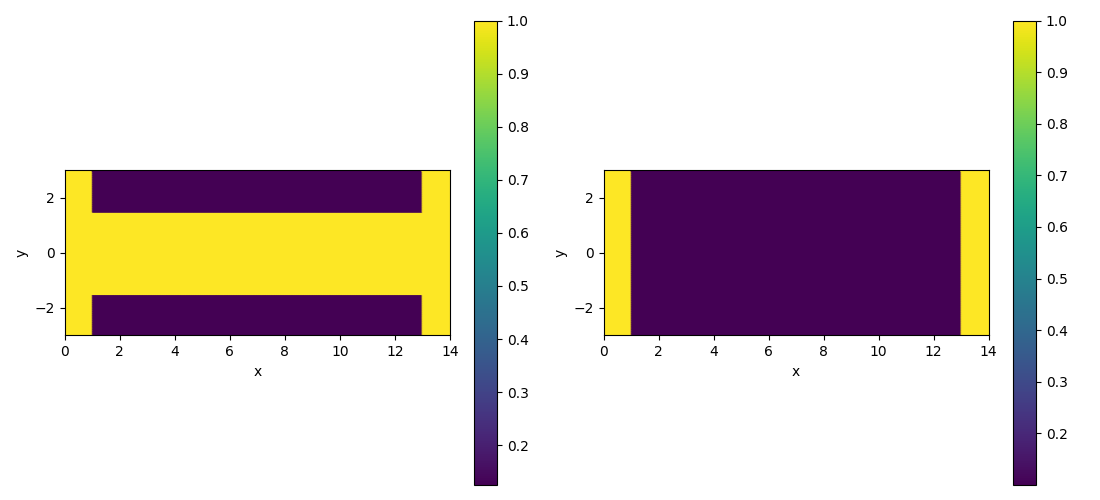

In [108]:
fig, axis = plt.subplots(1, 2, figsize=(11,5), squeeze=False)

sc = axis[0,0].scatter(particles.positions[:,0].cpu(), particles.positions[:,1].cpu(), c = rhoInitial.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])

sc = axis[0,1].scatter(particles.positions[:,0].cpu(), particles.positions[:,1].cpu(), c = Pi.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.tight_layout()

In [109]:
Lx = config.domain.max[0] - config.domain.min[0]
Ly = config.domain.max[1] - config.domain.min[1]
aspect = Ly / Lx

dx = Lx / (nx / aspect)
dy = Ly / nx

area = Lx * Ly / nx**2 * aspect


In [110]:
# Pinitial = Pi
# rhoInitial = rho_y


A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pi, rho = rhoInitial, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)

vInitial = torch.zeros_like(particles.positions)
internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(vInitial, dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

particles.internalEnergies = u_
particles.totalEnergies = totalEnergy
particles.pressures = P_
particles.soundspeeds = c_s
particles.velocities = vInitial
particles.densities = rhoInitial
particles.masses = area * rhoInitial

compressibleSystem = SimulationSystem(
    state=particles, 
    adjacency = adjacency, 
    domain = config.domain)

In [111]:

# rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)

# compressibleSystem.state.supports = h_optimal


In [112]:

adjacency = buildVerletList(
    compressibleSystem.state, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, compressibleSystem.state.densities, crkState = computeCRKFactors(compressibleSystem.state, config.domain, config.kernel, adjacency = adjacency)

In [113]:
enforceDirichlet(compressibleSystem.state, compressibleSystem.t, config.dt, config, compressibleSPHConfig)

In [114]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 12.5
plotter = visualize(
    particleState = compressibleSystem.state,
    domain = config.domain,
    quantities = {
        "A": compressibleSystem.state.densities,
        "B": h_optimal,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Densities",
            # mapping = Mapping.L2,
            # plottingOperation = OperationProperties(
            #     kernel = config.kernel,
            #     operation = WarpOperation.Curl,
            #     supportMode = SupportScheme.Gather,
            #     gradientMode = config.gradientMode,
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 256,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Support Radius",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=0.95,
            # vMax=2.05
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (8,7),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [115]:
from warpPlot import *

In [116]:
KE = (compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**2 / 2).sum()
IE = (compressibleSystem.state.masses * compressibleSystem.state.internalEnergies).sum()
TE = (compressibleSystem.state.masses * (compressibleSystem.state.internalEnergies + torch.linalg.norm(compressibleSystem.state.velocities, dim = -1)**
2)).sum()
print(f"Initial KE: {KE}, IE: {IE}, TE: {TE}, TE+PE: {TE}")

nonzeroEnergyMask = compressibleSystem.state.internalEnergies > 1e-8
print(f"Nonzero internal energy particles: {nonzeroEnergyMask.sum()} / {compressibleSystem.state.internalEnergies.shape[0]}")

Initial KE: 0.0, IE: 48.234375, TE: 48.234375, TE+PE: 48.234375
Nonzero internal energy particles: 153088 / 153088


In [117]:
from compressibleSPH.schemes.compSPH import compSPH_step
from compressibleSPH.modules.timestep.compressible import computeTimestep
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = config.dt) * 2/3
print(f"Initial timestep: {config.dt}")

Initial timestep: 0.0007333333293596903


In [118]:
runningState = compressibleSystem.initializeNewState()

In [119]:
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins
# schemeConfig.diffusionParams.C_q = 1.0



In [121]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping, CyclicColorMap
markerSize = 1
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            # colorMap = CyclicColorMap.twilight,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Velocity",
            mapping = Mapping.L2,
            # plottingOperation = OperationProperties(
            #     kernel = config.kernel,
            #     operation = WarpOperation.Curl,
            #     supportMode = SupportScheme.Gather,
            #     gradientMode = config.gradientMode,
            # ),
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap = True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Logarithmic,
            plotTitle = "density",
            gridVisualization = GridVisualization(
                resolution = 1024,
            ),
            vMin=0.2,
            vMax=7
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (12,3),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:

RFBOutputContext()

In [122]:
folderName = f"triple_{getCurrentTimestamp()}"
os.makedirs(f'output/{folderName}', exist_ok = True)
plotter.export(f'output/{folderName}/frame_00000.png', dpi = 200)

In [123]:
t_limit = 1.0
# config.dt = 1e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)


print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
print(nSteps//25)

Running with dt: 0.0007333333293596903, which gives nSteps: 1363
54


In [125]:
# os.makedirs('images/kevinHH_256_2', exist_ok = True)

t_limit = 5.0
# t_limit = 0.1
# config.dt = 1e-4
config.minDt = 1e-8
config.maxDt = 1e-3
config.dt = 2.5e-4
nSteps = int(t_limit / config.dt)
integrator = getIntegrator(config.integrationScheme)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 54
 
trajectory = []
runningState = compressibleSystem.initializeNewState()
priorStep = None
t = 0
i = 0
tq = tqdm(total = 1000, leave = True)

while t < t_limit:
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    # print(f"Step {i+1}/{nSteps}, time: {runningState.t:.4f}")
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    elapsed_time_ms = begin.elapsed_time(end)
    t = result.state.t.item() if isinstance(result.state.t, torch.Tensor) else result.state.t
    tq.n = int(t / t_limit * 1000)
    i = i + 1

    densityRatio = runningState.state.densities / result.state.state.densities
    
    # if (densityRatio < 0.7).any() or (densityRatio > 1.5).any():
    #     print(f"Warning: Density ratio out of bounds at step {i}, min: {densityRatio.min().item()}, max: {densityRatio.max().item()}")
    #     break

    runningState = result.state
    priorStep = result.stages[-1]
    # config.dt = computeTimestep(runningState, config, compressibleSPHConfig, dt = config.dt) 


    kineticEnergy_ = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy_ = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy_ + thermalEnergy_

    tq.set_description(f"{i:6d}: time: {t:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy_.cpu().item():.3g}, IE: {thermalEnergy_.cpu().item():.3g}, step time: {elapsed_time_ms:.3f}ms, adaptive dt: {config.dt:.3g}")
    
        
    trajectory.append((
        i,
        runningState.t,
        elapsed_time_ms,
        kineticEnergy_.cpu().item(),
        thermalEnergy_.cpu().item(),
        totalEnergy.cpu().item(),
    ))
    if (i % 10 == 0 and i > 0) or i == nSteps - 1:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'output/{folderName}/frame_{i:05d}.png', dpi = 300)
        # for ax in axis.flatten():
        #     ax.clear()
        # plotSod_(fig, axis, runningState.state, config, schemeConfig, config.domain, gamma, leftState, rightState, plotReference = True, plotLabels = False, scatter = True, t_ = runningState.t)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
    # print(f' Supports: Min: {runningState.state.supports.min().item()}, Max: {runningState.state.supports.max().item()}, Mean: {runningState.state.supports.mean().item()}')

Running with dt: 0.00025, which gives nSteps: 20000


  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
result = integrator.function(
    state = runningState,
    f = fn,
    dt = config.dt,
    config = config,
    compParams = compressibleSPHConfig,
    verbose = False,
    priorStep = priorStep
)

densityRatio = runningState.state.densities / result.state.state.densities

if (densityRatio < 0.7).any() or (densityRatio > 1.5).any():
    print(f"Warning: Density ratio out of bounds at step {i}, min: {densityRatio.min().item()}, max: {densityRatio.max().item()}")

print(runningState.state.densities.max(), runningState.state.densities.min())
print(result.state.state.densities.max(), result.state.state.densities.min())

In [ ]:
from integrators.euler import updateStateEuler

halfState = runningState.initializeNewState()
halfState = updateStateEuler(halfState, priorStep.update, config.dt * 0.5, False)

In [ ]:
# halfState.adjacency = None

In [ ]:
config.verletScale

In [ ]:
stepResult = fn(halfState, config.dt * 0.5, config, compressibleSPHConfig)

In [ ]:
nnrsPrev = runningState.adjacency.numNeighbors
print(f'Number of neighbors: min {nnrsPrev.min().item()}, max {nnrsPrev.max().item()}, mean {nnrsPrev.to(torch.float32).mean().item()}')
nnrsCurr = stepResult[1].numNeighbors
print(f'Number of neighbors: min {nnrsCurr.min().item()}, max {nnrsCurr.max().item()}, mean {nnrsCurr.to(torch.float32).mean().item()}')

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = nnrsPrev.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = nnrsCurr.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = runningState.state.densities.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = stepResult[2].densities.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)
sc = axis[0,0].scatter(runningState.state.positions[:,0].cpu(), runningState.state.positions[:,1].cpu(), c = runningState.state.supports.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,0])
sc = axis[0,1].scatter(stepResult[2].positions[:,0].cpu(), stepResult[2].positions[:,1].cpu(), c = stepResult[2].supports.cpu(), s = 1, cmap = 'viridis')
fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')
fig.tight_layout()

In [ ]:
import copy
queryPositions = halfState.state.positions
referencePositions = halfState.state.positions
querySupports = halfState.state.supports
referenceSupports = halfState.state.supports
domain = copy.deepcopy(config.domain)
domain.min = domain.min
domain.max = domain.max

verletScale = 1.0
mode = SupportScheme.Scatter

adjacency, hmap = radiusSearchCompactHashMap_(
    queryPositions, referencePositions,
    querySupports * verletScale, referenceSupports * verletScale,
    domain.periodic, domain, mode, hashMapLength=queryPositions.shape[0] + 1, returnCompactHashMap = True
)

print(adjacency.numNeighbors.min(), adjacency.numNeighbors.max(), adjacency.numNeighbors.to(torch.float).mean())

In [ ]:

print(torch.sum(adjacency.i == adjacency.j), queryPositions.shape[0])

In [ ]:
print(hmap.hashTable)
print(hmap.sortedCellTable.shape)

In [ ]:

queryPositions = halfState.state.positions.to(torch.float64)
referencePositions = halfState.state.positions.to(torch.float64)
querySupports = halfState.state.supports.to(torch.float64)
referenceSupports = halfState.state.supports.to(torch.float64)
domain = copy.deepcopy(config.domain)
domain.min = domain.min.to(torch.float64)
domain.max = domain.max.to(torch.float64)

In [ ]:
domainDescription = config.domain
periodicity = domainDescription.periodic

mode_uint = supportSchemeToUint(mode)
# mode_map = {'gather': 1, 'scatter': 2, 'symmetric': 3, 'superSymmetric': 4, ''}
# mode_uint = mode_map.get(mode, 0)
# if mode_uint == 0:
    # raise ValueError(f"Invalid mode: {mode}. Supported modes are: {list(mode_map.keys())}")
    
minDomain = domainDescription.min if domainDescription.min is not None else None
maxDomain = domainDescription.max if domainDescription.max is not None else None
hMax = computeGridSupport(querySupports, referenceSupports, mode)
minD, maxD = getDomainExtents(referencePositions, minDomain, maxDomain)
x = torch.vstack([component if not periodic else torch.remainder(component - minD[i], maxD[i] - minD[i]) + minD[i] for i, (component, periodic) in enumerate(zip(referencePositions.mT, periodicity))]).mT
y = torch.vstack([component if not periodic else torch.remainder(component - minD[i], maxD[i] - minD[i]) + minD[i] for i, (component, periodic) in enumerate(zip(queryPositions.mT, periodicity))]).mT

sortedLinear, sortIndex, numCells, qMin, qMax, hCell = sortReferenceParticles(x, hMax, minD, maxD)


sortedPositions = x[sortIndex,:]

cellIndices, cellCounters = torch.unique_consecutive(sortedLinear, return_counts=True, return_inverse=False)
cellCounters = cellCounters.to(torch.int32)
# Needs to zero padded for the indexing to work properly as the 0th cell is valid and cumsum doesn't include the first element

cumCell = torch.hstack((torch.tensor([0], device = cellIndices.device, dtype=cellCounters.dtype),torch.cumsum(cellCounters,dim=0)))[:-1].to(torch.int32)

sortedIndices = torch.floor((sortedPositions - qMin) / to_numpy(hCell)).to(torch.int32)
for d in range(sortedIndices.shape[1]):
    sortedIndices[:, d] = torch.clamp(sortedIndices[:, d], 0, int(numCells[d].item()) - 1)
cellGridIndices = sortedIndices[cumCell,:]
cellTable = torch.stack((cellIndices, cumCell, cellCounters), dim = 1)

warpDevice = castTorchToWarp(queryPositions).device
torchDevice = queryPositions.device

cellGridIndices_warp = castTorchToWarp(cellGridIndices)
hashedIndices_warp = wp.zeros(sortedIndices.shape[0], dtype=wp.uint32, device=warpDevice)
wp.launch(hashCells, dim=sortedIndices.shape[0], inputs=[sortedIndices, wp.uint32(2), hashedIndices_warp], device=warpDevice)
hashedIndices = wp.to_torch(hashedIndices_warp).to(torch.int32)

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(11,10), squeeze=False)

q = sortedLinear
qUnique = torch.unique(q)
colors = torch.rand((qUnique.shape[0], 3), device = queryPositions.device)
c = colors[torch.searchsorted(qUnique, q)]

s = 1

sc = axis[0,0].scatter(sortedPositions[:,0].cpu(), sortedPositions[:,1].cpu(), c = c.cpu(), s = s, cmap = 'viridis')
# fig.colorbar(sc, ax = axis[0,0])

q = hashedIndices
qUnique = torch.unique(q)
colors = torch.rand((qUnique.shape[0], 3), device = queryPositions.device)
c = colors[torch.searchsorted(qUnique, q)]

sc = axis[0,1].scatter(sortedPositions[:,0].cpu(), sortedPositions[:,1].cpu(), c = c.cpu(), s = s, cmap = 'viridis')
# fig.colorbar(sc, ax = axis[0,1])
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(config.domain.min[0].item(), config.domain.max[0].item())
    ax.set_ylim(config.domain.min[1].item(), config.domain.max[1].item())
    ax.set_xlabel('x')
    ax.set_ylabel('y')

In [ ]:
ffmpeg -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4
ffmpeg -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png
ffmpeg -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif

In [ ]:
cState = runningState.initializeNewState()
currentState = cState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, currentState.densities, crkState = computeCRKFactors(currentState, config.domain, config.kernel, adjacency = adjacency)


In [ ]:
def limiterVL(x):
    # if x <= 0.0:
        # return 0.0
    # x = wp.min(x, scalar_t(1.0e6))
    # vL = 2.0 / (1.0 + x)
    # return x * vL*vL

    return (x + torch.abs(x)) / (1.0 + torch.abs(x))

xx = torch.linspace(0, 1, 1000)
yy = limiterVL(xx)

fig, ax = plt.subplots()
ax.plot(xx.cpu(), yy.cpu())
ax.set_title("Van Leer Limiter")
ax.set_xlabel("x")
ax.set_ylabel("limiterVL(x)")
plt.grid()


In [ ]:
velocityGradient = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    # queryVolumes = apparentVolume,
    # crkState= crkState,
)

velocityGradientCRK = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Gradient,
        supportMode = SupportScheme.Scatter, # E.3
        gradientMode = GradientScheme.Difference, # E.3
    ),
    queryValues = currentState.velocities,
    domain = config.domain,
    adjacency = adjacency,
    queryVolumes = apparentVolume,
    crkState= crkState,
)

In [ ]:
trace = torch.einsum('...ii', velocityGradient)

traces = torch.eye(velocityGradient.shape[1], device=velocityGradient.device) * trace.view(-1, 1, 1) / velocityGradient.shape[1]

Shear = (velocityGradient + velocityGradient.transpose(1,2))/2 - traces
Rotation = (velocityGradient - velocityGradient.transpose(1,2)) / 2

In [ ]:
matrix = velocityGradient# - velocityGradientCRK
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, DivergingColorMap, Mapping
markerSize = 2
plotter = visualize(
    particleState = currentState,
    domain = config.domain,
    quantities = {
        "A": matrix[:,0,0],
        "B": matrix[:,0,1],
        "C": matrix[:,1,0],
        "D": matrix[:,1,1],
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "C": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
        "D": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = '''AB
    CD''',
    figsize= (11,10),
    # backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

In [ ]:
display(plotter.fig)